# [1교시]

## runpod에서 실습

### 기본환경 셋팅

- exaone35
    - data[폴더]
    - outputs[폴더]
    - scripts[폴더]
    - requirements-train.txt[파일]
    - exaone.ipynb[파일]

- cd /workspace/exaone35

- bash scripts/setup_runpod.sh

- source .venv/bin/activate

In [ ]:
from pathlib import Path
import os
import sys

PROJECT_DIR = Path('/workspace/exaone35')
if not PROJECT_DIR.exists():
    PROJECT_DIR = Path.cwd()

os.chdir(PROJECT_DIR)

MODEL_ID = 'LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct'
SYSTEM_PROMPT = 'You are EXAONE model from LG AI Research, a helpful assistant.'

os.environ['HF_HOME'] = '/workspace/.cache/huggingface'
os.environ['MODEL_ID'] = MODEL_ID
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['DISABLE_DOTENV'] = '1'
os.environ.pop('HF_TOKEN', None)

print('project_dir:', PROJECT_DIR)
print('python:', sys.executable)
print('hf_home:', os.environ['HF_HOME'])
print('model_id:', MODEL_ID)
print('disable_dotenv:', os.environ['DISABLE_DOTENV'])

### GPU 설정 확인

In [ ]:
!nvidia-smi
!python3 --version || true

### BF16 LoFA 기본으로 사용
- gpu 사용 가능 여부 확인

In [ ]:
import importlib.metadata as metadata
import torch

packages = ['torch', 'transformers', 'accelerate', 'datasets', 'peft', 'trl', 'bitsandbytes', 'huggingface_hub']
for name in packages:
    try:
        print(f'{name}:', metadata.version(name))
    except metadata.PackageNotFoundError:
        print(f'{name}: NOT_INSTALLED')

print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))
    print('torch cuda:', torch.version.cuda)
    print('bf16 supported:', torch.cuda.is_bf16_supported())
    free, total = torch.cuda.mem_get_info(0)
    print('gpu memory free GB:', round(free / 1024**3, 2))
    print('gpu memory total GB:', round(total / 1024**3, 2))

### 허깅페이스 로그인
- 대부분 고성능 모델은  허깅페이스에서 사용신청을 하고 권한을 얻은다음 로그인을해야 사용가능

In [ ]:
from huggingface_hub import notebook_login

os.environ.pop('HF_TOKEN', None)
notebook_login(skip_if_logged_in=False)

### 우리가 전달한 토큰값으로 로그인이 되었다면 아래 셀의 출력을통해 확인

In [ ]:
from huggingface_hub import get_token, whoami

HF_TOKEN = get_token()
if not HF_TOKEN:
    raise RuntimeError('Hugging Face 토큰이 저장되지 않았습니다. 로그인 셀을 다시 실행하세요.')

info = whoami(token=HF_TOKEN)
print('logged in user:', info.get('name'))
print('token prefix:', HF_TOKEN[:6] + '***')

### 셈플데이터 구조 확인
- system : 모델역활 설명
- user : 질문
- assistant : 모델이 학습해야할 정답 답변

In [ ]:
import json
from pathlib import Path

TRAIN_FILE = Path('data/train.jsonl')
VALID_FILE = Path('data/valid.jsonl')
VALID_ROLES = {'system', 'user', 'assistant'}

def validate_jsonl(path: Path) -> int:
    count = 0
    with path.open(encoding='utf-8') as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            count += 1
            row = json.loads(line)
            messages = row.get('messages')
            if not isinstance(messages, list) or not messages:
                raise ValueError(f'{path}:{line_no}: messages must be a non-empty list')
            if messages[-1].get('role') != 'assistant':
                raise ValueError(f'{path}:{line_no}: last message must be assistant')
            roles = [m.get('role') for m in messages]
            if 'user' not in roles or 'assistant' not in roles:
                raise ValueError(f'{path}:{line_no}: user and assistant messages are required')
            for idx, message in enumerate(messages):
                if message.get('role') not in VALID_ROLES:
                    raise ValueError(f'{path}:{line_no}: invalid role at message {idx}')
                if not isinstance(message.get('content'), str) or not message['content'].strip():
                    raise ValueError(f'{path}:{line_no}: empty content at message {idx}')
    return count

print('train rows:', validate_jsonl(TRAIN_FILE))
print('valid rows:', validate_jsonl(VALID_FILE))
print('validation: OK')

### 데이터 예시 보기

In [ ]:
with TRAIN_FILE.open(encoding='utf-8') as f:
    first_sample = json.loads(next(f))

first_sample

### 데이터셋 로드(만들기)

In [ ]:
from datasets import load_dataset

raw_dataset = load_dataset('json', data_files={
    'train': str(TRAIN_FILE),
    'validation': str(VALID_FILE),
})

raw_dataset

### 모델 로드

In [ ]:
from transformers import AutoTokenizer

DTYPE = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
print('selected dtype:', DTYPE)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    token=HF_TOKEN,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

print('vocab size:', len(tokenizer))
print('pad token:', tokenizer.pad_token, tokenizer.pad_token_id)
print('eos token:', tokenizer.eos_token, tokenizer.eos_token_id)

In [ ]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map='auto',
    trust_remote_code=True,
    low_cpu_mem_usage=True,
    token=HF_TOKEN,
)
model.eval()

first_device = next(model.parameters()).device
print('loaded:', True)
print('first parameter device:', first_device)
if torch.cuda.is_available():
    print('memory allocated GB:', round(torch.cuda.memory_allocated() / 1024**3, 3))
    print('memory reserved GB:', round(torch.cuda.memory_reserved() / 1024**3, 3))

### 원본 모델 추론

In [ ]:
prompt = '한국어 형태소 분석이 왜 중요한지 짧게 설명해줘.'
messages = [
    {'role': 'system', 'content': SYSTEM_PROMPT},
    {'role': 'user', 'content': prompt},
]

# 최신 Transformers에서는 apply_chat_template가 BatchEncoding을 반환할 수 있습니다.
# 그래서 Tensor 하나를 generate에 넘기지 않고, input_ids/attention_mask를 dict로 풀어 전달합니다.
encoded = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors='pt',
    return_dict=True,
).to(first_device)

inputs = dict(encoded)
prompt_length = inputs['input_ids'].shape[-1]

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

new_tokens = output_ids[0][prompt_length:]
response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
print(response)

학습전 gpu메모리 정리

In [ ]:
import gc
del encoded
del inputs
del output_ids
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

if torch.cuda.is_available():
    print('memory allocated GB:', round(torch.cuda.memory_allocated() / 1024**3, 3))
    print('memory reserved GB:', round(torch.cuda.memory_reserved() / 1024**3, 3))

### 학습 설정값 정의

In [ ]:
OUTPUT_DIR = Path('outputs/exaone35-2.4b-koqa-lora')
MAX_SEQ_LENGTH = 2048
NUM_TRAIN_EPOCHS = 1
PER_DEVICE_TRAIN_BATCH_SIZE = 1
PER_DEVICE_EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 2e-4
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# EXAONE의 선형층 이름입니다. all-linear를 쓰면 lm_head까지 포함될 수 있어
# tied embedding 구조에서 PEFT 호환 문제가 생길 수 있으므로 명시적으로 지정합니다.
LORA_TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'out_proj', 'c_fc_0', 'c_fc_1', 'c_proj']

print('output_dir:', OUTPUT_DIR)
print('max_seq_length:', MAX_SEQ_LENGTH)
print('epochs:', NUM_TRAIN_EPOCHS)
print('lora targets:', LORA_TARGET_MODULES)

In [ ]:
def tokenize_chat_example(example):
    messages = example['messages']
    full_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    prompt_text = tokenizer.apply_chat_template(
        messages[:-1],
        tokenize=False,
        add_generation_prompt=True,
    )

    full = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        add_special_tokens=False,
    )
    prompt = tokenizer(
        prompt_text,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        add_special_tokens=False,
    )

    input_ids = full['input_ids']
    labels = input_ids.copy()
    prompt_length = min(len(prompt['input_ids']), len(labels))
    labels[:prompt_length] = [-100] * prompt_length

    return {
        'input_ids': input_ids,
        'attention_mask': full['attention_mask'],
        'labels': labels,
    }

tokenized_dataset = raw_dataset.map(
    tokenize_chat_example,
    remove_columns=raw_dataset['train'].column_names,
    desc='Tokenizing chat data',
)

tokenized_dataset

In [ ]:
from dataclasses import dataclass
from typing import Any

@dataclass
class CausalDataCollator:
    tokenizer: Any

    def __call__(self, features):
        labels = [feature.pop('labels') for feature in features]
        batch = self.tokenizer.pad(features, padding=True, return_tensors='pt')
        max_length = batch['input_ids'].shape[1]
        padded_labels = []
        for label in labels:
            padded_labels.append(label + [-100] * (max_length - len(label)))
        batch['labels'] = torch.tensor(padded_labels, dtype=torch.long)
        return batch

collator = CausalDataCollator(tokenizer)
print('collator ready')

### LoRA 학습 모델 구성

여기서 base model을 다시 로드하고 LoRA adapter를 붙입니다.

코드에서 하는 일:

- EXAONE base model을 BF16으로 GPU에 로드합니다.
- gradient checkpointing을 켜서 메모리를 줄입니다.
- PEFT의 `LoraConfig`로 LoRA 학습 대상을 설정합니다.
- 전체 파라미터 중 실제 학습되는 파라미터 수를 출력합니다.

In [ ]:
from peft import LoraConfig, get_peft_model
import types


def patch_exaone_embedding_access(model):
    """PEFT가 EXAONE의 입력/출력 embedding을 찾을 수 있게 보정합니다."""
    if not hasattr(model, 'transformer') or not hasattr(model.transformer, 'wte'):
        return model

    def get_input_embeddings_for_lm(self):
        return self.transformer.wte

    def set_input_embeddings_for_lm(self, value):
        self.transformer.wte = value

    def get_output_embeddings_for_lm(self):
        return self.lm_head

    def set_output_embeddings_for_lm(self, value):
        self.lm_head = value

    def get_input_embeddings_for_base(self):
        return self.wte

    def set_input_embeddings_for_base(self, value):
        self.wte = value

    model.get_input_embeddings = types.MethodType(get_input_embeddings_for_lm, model)
    model.set_input_embeddings = types.MethodType(set_input_embeddings_for_lm, model)
    model.get_output_embeddings = types.MethodType(get_output_embeddings_for_lm, model)
    model.set_output_embeddings = types.MethodType(set_output_embeddings_for_lm, model)
    model.transformer.get_input_embeddings = types.MethodType(get_input_embeddings_for_base, model.transformer)
    model.transformer.set_input_embeddings = types.MethodType(set_input_embeddings_for_base, model.transformer)
    return model


train_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map={'': 0} if torch.cuda.is_available() else None,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
    token=HF_TOKEN,
)

# gradient_checkpointing_enable과 PEFT 모두 get_input_embeddings를 사용하므로
# 두 기능을 켜기 전에 EXAONE embedding 접근자를 먼저 보정합니다.
train_model = patch_exaone_embedding_access(train_model)
train_model.config.use_cache = False
train_model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    task_type='CAUSAL_LM',
    target_modules=LORA_TARGET_MODULES,
)

train_model = get_peft_model(train_model, lora_config)
train_model.print_trainable_parameters()

if torch.cuda.is_available():
    print('memory allocated GB:', round(torch.cuda.memory_allocated() / 1024**3, 3))

### Trainer 설정

Transformers `Trainer`로 학습 루프를 구성합니다.

코드에서 하는 일:

- batch size와 gradient accumulation을 설정합니다.
- BF16 학습을 켭니다.
- validation 평가는 일정 step마다 수행합니다.
- 학습 로그는 외부 서비스로 보내지 않고 노트북에만 출력합니다.

In [ ]:
import inspect
from transformers import Trainer, TrainingArguments

training_kwargs = dict(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_TRAIN_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    logging_steps=1,
    save_strategy='epoch',
    save_total_limit=2,
    bf16=DTYPE == torch.bfloat16,
    fp16=DTYPE == torch.float16,
    gradient_checkpointing=True,
    optim='adamw_torch',
    report_to='none',
    remove_unused_columns=False,
)

signature = inspect.signature(TrainingArguments.__init__)
if 'eval_strategy' in signature.parameters:
    training_kwargs['eval_strategy'] = 'steps'
else:
    training_kwargs['evaluation_strategy'] = 'steps'
training_kwargs['eval_steps'] = 10

training_args = TrainingArguments(**training_kwargs)

trainer = Trainer(
    model=train_model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    data_collator=collator,
)

print('trainer ready')

### LoRA smoke test 학습 실행

이 셀에서 실제 학습이 시작됩니다.

성공 기준:

- loss가 출력됩니다.
- 학습이 끝까지 완료됩니다.
- adapter 파일이 output 폴더에 저장됩니다.

OOM이 발생하면  `MAX_SEQ_LENGTH`를 1024로 줄이거나 QLoRA를 사용합니다.

In [ ]:
trainer.train()
trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

print('saved:', OUTPUT_DIR)
print('adapter_config:', (OUTPUT_DIR / 'adapter_config.json').exists())
print('adapter_model:', (OUTPUT_DIR / 'adapter_model.safetensors').exists())

### 저장된 adapter 파일 확인

LoRA 학습은 base model 전체를 저장하지 않습니다. adapter 가중치와 설정만 저장합니다.

중요 파일:

- `adapter_config.json`
- `adapter_model.safetensors`

추론할 때는 base model과 adapter를 함께 로드합니다.

In [ ]:
for path in sorted(OUTPUT_DIR.glob('*')):
    print(path.name, path.stat().st_size)

### 학습 모델 메모리 정리

adapter 추론 테스트를 위해 학습용 모델과 Trainer를 삭제하고 GPU 메모리를 정리합니다.

In [ ]:
import gc
del trainer
del train_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

if torch.cuda.is_available():
    print('memory allocated GB:', round(torch.cuda.memory_allocated() / 1024**3, 3))
    print('memory reserved GB:', round(torch.cuda.memory_reserved() / 1024**3, 3))

### LoRA adapter 추론 모델 로드

학습된 adapter를 base model 위에 올려 추론합니다.

코드에서 하는 일:

- base EXAONE 모델을 다시 로드합니다.
- `PeftModel.from_pretrained`로 LoRA adapter를 붙입니다.
- eval 모드로 전환합니다.

In [ ]:
from peft import PeftModel

base_for_lora = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map={'': 0} if torch.cuda.is_available() else None,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
    token=HF_TOKEN,
)
base_for_lora = patch_exaone_embedding_access(base_for_lora)

lora_model = PeftModel.from_pretrained(base_for_lora, str(OUTPUT_DIR))
lora_model.eval()

print('lora model loaded')
print('device:', next(lora_model.parameters()).device)

### LoRA adapter 추론 실행

학습된 adapter가 정상 로드되는지 확인합니다.

smoke test 데이터는 작기 때문에 큰 품질 향상을 기대하지 않습니다. 여기서는 adapter 로드와 생성 동작이 성공하는지가 핵심입니다.

In [ ]:
test_prompt = '한국어 Q&A 데이터셋을 만들 때 가장 중요한 점은 뭐야?'
messages = [
    {'role': 'system', 'content': SYSTEM_PROMPT},
    {'role': 'user', 'content': test_prompt},
]

encoded = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors='pt',
    return_dict=True,
).to(next(lora_model.parameters()).device)

inputs = dict(encoded)
prompt_length = inputs['input_ids'].shape[-1]

with torch.no_grad():
    output_ids = lora_model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

new_tokens = output_ids[0][prompt_length:]
print(tokenizer.decode(new_tokens, skip_special_tokens=True).strip())

# [2교시]

### 환경설정
- chroma(벡터Db) : 로컬 인메모리 모드지원, 서버불필요
- Neo4j python driver : Neo4j 서버통신
- sentence-transformers : 텍스트 임베딩
- sckit-learn : PCA 데이터 분석 

In [31]:
!pip install chromadb sentence-transformers neo4j matplotlib networkx scikit-learn -q

In [32]:
# 설치확인
import chromadb
import neo4j
import sentence_transformers
print(chromadb.__version__, neo4j.__version__, sentence_transformers.__version__)

1.5.9 6.2.0 5.5.1


### 벡터DB
- 고차원벡터(Embedding)를 저장, 유사도검색을 수행하는데 특화
- RAG 핵심 인프라 : LLM의 외부 지식검색에 필수적
- 메타데이터 필터링 : 벡터검색 + 조건 필터링 동시 지원

### 벡터DB 종류
- Chroma : 경량                : 학습(프로토타입)
- Pinecone : 관리형 ,고 가용성   : 대용량 프로젝트
- Weaviate : 멀티모달           : 복합검색
- Milvus : 분선처리 GPU         : 대용량 프로젝트
- FAISS : Meta 오픈소스, 초고속  : 연구용(벤치마크)

In [33]:
import chromadb
client = chromadb.Client()  # in-memory
# client = chromadb.PersistentClient(path='./outputs')
client.heartbeat()

1779776244224209000

### collection 생성
    - 벡터들의 논리적 그룹(RDBMS 테이블 개념)
    - 거리함수 : cosine(기본)

In [34]:
collection = client.get_or_create_collection(
    name = 'korean_foods',
    metadata={'hnsw:space':'cosine'}
)
print(f'컬렉션 이름 : {collection.name}') 
print(f'현재 문서 수 : {collection.count()}')

컬렉션 이름 : korean_foods
현재 문서 수 : 10


In [35]:
documents = [
    "김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다.",
    "불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전통 요리입니다.",
    "비빔밥은 밥 위에 다양한 나물과 고추장을 넣고 비벼 먹는 음식입니다.",
    "된장찌개는 된장을 풀어 두부, 감자, 호박 등을 넣고 끓인 찌개입니다.",
    "삼겹살은 돼지 뱃살을 구워 쌈 채소에 싸서 먹는 인기 있는 요리입니다.",
    "떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 길거리 음식입니다.",
    "냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미입니다.",
    "잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음식입니다.",
    "갈비탕은 소갈비를 오랫동안 끓여 만든 깊은 맛의 탕 요리입니다.",
    "순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓인 매운 찌개입니다.",
]

metadatas = [
    {"category": "찌개", "main_ingredient": "돼지고기", "spicy": True},
    {"category": "구이", "main_ingredient": "소고기", "spicy": False},
    {"category": "밥",  "main_ingredient": "채소",   "spicy": True},
    {"category": "찌개", "main_ingredient": "된장",   "spicy": False},
    {"category": "구이", "main_ingredient": "돼지고기", "spicy": False},
    {"category": "분식", "main_ingredient": "떡",     "spicy": True},
    {"category": "면",  "main_ingredient": "메밀",   "spicy": False},
    {"category": "볶음", "main_ingredient": "당면",   "spicy": False},
    {"category": "탕",  "main_ingredient": "소고기", "spicy": False},
    {"category": "찌개", "main_ingredient": "순두부", "spicy": True},
]

ids = [f'food_{i:03d}' for i in range(len(documents))]
print(f'ids = {ids}')

collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)
print(f'{collection.count()}개 문서 추가 완료')
for doc_id, doc in zip(ids,documents):
    print(f'    {doc_id} : {doc[:30]}...')

ids = ['food_000', 'food_001', 'food_002', 'food_003', 'food_004', 'food_005', 'food_006', 'food_007', 'food_008', 'food_009']
10개 문서 추가 완료
    food_000 : 김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인...
    food_001 : 불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전...
    food_002 : 비빔밥은 밥 위에 다양한 나물과 고추장을 넣고 비벼 먹...
    food_003 : 된장찌개는 된장을 풀어 두부, 감자, 호박 등을 넣고 ...
    food_004 : 삼겹살은 돼지 뱃살을 구워 쌈 채소에 싸서 먹는 인기 ...
    food_005 : 떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 ...
    food_006 : 냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미...
    food_007 : 잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음...
    food_008 : 갈비탕은 소갈비를 오랫동안 끓여 만든 깊은 맛의 탕 요...
    food_009 : 순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓...


### 유사도 검색

In [36]:
query = '매운 국물 요리가 먹고 싶어요'
results = collection.query(
    query_texts=[query],
    n_results=5 # top_5
)
for doc, meta, dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    similarity = 1- dist # 코사인거리 -> 유사도 변환
    print(doc, meta, dist)

떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 길거리 음식입니다. {'spicy': True, 'category': '분식', 'main_ingredient': '떡'} 0.15752524137496948
순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓인 매운 찌개입니다. {'spicy': True, 'category': '찌개', 'main_ingredient': '순두부'} 0.19012266397476196
김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다. {'main_ingredient': '돼지고기', 'spicy': True, 'category': '찌개'} 0.21276319026947021
냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미입니다. {'category': '면', 'main_ingredient': '메밀', 'spicy': False} 0.2229100465774536
잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음식입니다. {'main_ingredient': '당면', 'category': '볶음', 'spicy': False} 0.25143176317214966


# [3교시]

In [37]:
queries = [
    "고기를 구워서 먹는 음식",
    "시원한 여름 음식 추천해주세요",
    "명절에 먹는 전통 음식",
]

# 각 질문에 대해서 top-3 문장을 출력
for query in queries:
    results = collection.query(
        query_texts=[query],
        n_results=3  # top_5
    )
    print(f'\n질문 : {query}')
    for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')


질문 : 고기를 구워서 먹는 음식
유사도(0.7897407412528992) 문서:불고기는 간장 양념에 재운 ...,메타:{'category': '구이', 'spicy': False, 'main_ingredient': '소고기'}
유사도(0.7736005783081055) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'category': '분식', 'spicy': True, 'main_ingredient': '떡'}
유사도(0.7421424388885498) 문서:비빔밥은 밥 위에 다양한 나...,메타:{'main_ingredient': '채소', 'spicy': True, 'category': '밥'}

질문 : 시원한 여름 음식 추천해주세요
유사도(0.7804622650146484) 문서:비빔밥은 밥 위에 다양한 나...,메타:{'category': '밥', 'main_ingredient': '채소', 'spicy': True}
유사도(0.7059831023216248) 문서:냉면은 메밀 면을 차가운 육...,메타:{'spicy': False, 'category': '면', 'main_ingredient': '메밀'}
유사도(0.6690664887428284) 문서:김치찌개는 돼지고기와 김치를...,메타:{'main_ingredient': '돼지고기', 'spicy': True, 'category': '찌개'}

질문 : 명절에 먹는 전통 음식
유사도(0.773314356803894) 문서:비빔밥은 밥 위에 다양한 나...,메타:{'category': '밥', 'spicy': True, 'main_ingredient': '채소'}
유사도(0.7512445449829102) 문서:냉면은 메밀 면을 차가운 육...,메타:{'category': '면', 'main_ingredient': '메밀', 'spicy': False}
유사도(0.7327145338058472) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'spicy': True, 'category'

## 메타데이터 필터링
- 기본 벡터유사도 검색 + 조건필터
- 문맥을 통해 유사한 문장을 찾으면서 특정조건을 만족하는 결과

In [38]:
# 매운음식만 검색 : 필터를 매운음식중에 국물요리 
results = collection.query(
        query_texts=["따뜻한 국물 요리"],
        n_results=3,  # top_5
        where={'spicy':True}  # 매운 음식만
    )
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')

유사도(0.7249371409416199) 문서:김치찌개는 돼지고기와 김치를...,메타:{'category': '찌개', 'main_ingredient': '돼지고기', 'spicy': True}
유사도(0.6877250671386719) 문서:순두부찌개는 부드러운 순두부...,메타:{'spicy': True, 'main_ingredient': '순두부', 'category': '찌개'}
유사도(0.6661773324012756) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'main_ingredient': '떡', 'spicy': True, 'category': '분식'}


In [39]:
# 카테고리가 찌개인 음식
# 카테고리가 구이인 음식
# 소고기 또는 돼지고기를 사용하고, 매운 음식이 아닌 것

In [40]:
results = collection.query(
        query_texts=["따뜻한 국물 요리"],
        n_results=3,  # top_3
        where={'category':'찌개'}
    )
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')

유사도(0.7249371409416199) 문서:김치찌개는 돼지고기와 김치를...,메타:{'main_ingredient': '돼지고기', 'spicy': True, 'category': '찌개'}
유사도(0.6877250671386719) 문서:순두부찌개는 부드러운 순두부...,메타:{'main_ingredient': '순두부', 'spicy': True, 'category': '찌개'}
유사도(0.6491010189056396) 문서:된장찌개는 된장을 풀어 두부...,메타:{'spicy': False, 'category': '찌개', 'main_ingredient': '된장'}


In [41]:
results = collection.query(
        query_texts=["고기종류의 음식"],
        n_results=3,  # top_3
        where={'category':'구이'}
    )
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')

유사도(0.49335598945617676) 문서:불고기는 간장 양념에 재운 ...,메타:{'spicy': False, 'category': '구이', 'main_ingredient': '소고기'}
유사도(0.3948414921760559) 문서:삼겹살은 돼지 뱃살을 구워 ...,메타:{'main_ingredient': '돼지고기', 'spicy': False, 'category': '구이'}


In [42]:
results = collection.query(
        query_texts=["고기종류의 음식"],
        n_results=3,  # top_3
        where={
            "$and": [
                { 'main_ingredient':{"$in":["소고기","돼지고기"]} },
                { 'spicy':False }
            ]
        }

    )
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        similarity = 1- dist # 코사인거리->유사도 변환            
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')

유사도(0.49335598945617676) 문서:불고기는 간장 양념에 재운 ...,메타:{'category': '구이', 'main_ingredient': '소고기', 'spicy': False}
유사도(0.47859489917755127) 문서:갈비탕은 소갈비를 오랫동안 ...,메타:{'spicy': False, 'main_ingredient': '소고기', 'category': '탕'}
유사도(0.3948414921760559) 문서:삼겹살은 돼지 뱃살을 구워 ...,메타:{'main_ingredient': '돼지고기', 'spicy': False, 'category': '구이'}


### 커스텀 임베딩 모델 사용
- Chroma 기본 임베딩 대신 Sentence-Transformer 다국어 모델을 사용해서 한국어 검색 성능을 향상

In [ ]:
from chromadb.utils import embedding_functions
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name=''
)

In [ ]:
# 커스텀 임베딩 모델용 컬렉션 생성
collection_custom =  client.get_or_create_collection(
    name = 'korean_foods_custom',
    embedding_function=st_ef,
    metadata={'hnsw:space':"cosine"}
)
# 문서추가
collection_custom.add(
    documents=documents,
    metadatas=metadatas,
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
)
# 기본 vs 커스텀 임베딩
test_query = '뜨끈한 국물이 있는 겨울 음식'
r1 = collection.query(query_texts=[test_query],n_results=3)
r2 = collection_custom.query(query_texts=[test_query],n_results=3)

def showResult(results):
    for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
            similarity = 1- dist # 코사인거리->유사도 변환            
            print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')   
showResult(r1)
print('\n')
showResult(r2)

# [4교시]

In [44]:
from chromadb.utils import embedding_functions
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='jhgan/ko-sroberta-multitask'
)

In [45]:
# 커스텀 임베딩 모델용 컬렉션 생성
collection_custom =  client.get_or_create_collection(
    name = 'korean_foods_custom',
    embedding_function=st_ef,
    metadata={'hnsw:space':"cosine"}
)
# 문서추가
collection_custom.add(
    documents=documents,
    metadatas=metadatas,
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
)
# 기본 vs 커스텀 임베딩
test_query = '뜨끈한 국물이 있는 겨울 음식'
r1 = collection.query(query_texts=[test_query],n_results=3)
r2 = collection_custom.query(query_texts=[test_query],n_results=3)

def showResult(results):
    for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
            similarity = 1- dist # 코사인거리->유사도 변환            
            print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')   
showResult(r1)
print('\n')
showResult(r2)

유사도(0.7687559127807617) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'main_ingredient': '떡', 'category': '분식', 'spicy': True}
유사도(0.742857813835144) 문서:김치찌개는 돼지고기와 김치를...,메타:{'main_ingredient': '돼지고기', 'category': '찌개', 'spicy': True}
유사도(0.6985085010528564) 문서:냉면은 메밀 면을 차가운 육...,메타:{'category': '면', 'main_ingredient': '메밀', 'spicy': False}


유사도(0.5396612286567688) 문서:냉면은 메밀 면을 차가운 육...,메타:{'main_ingredient': '메밀', 'spicy': False, 'category': '면'}
유사도(0.46233463287353516) 문서:순두부찌개는 부드러운 순두부...,메타:{'category': '찌개', 'main_ingredient': '순두부', 'spicy': True}
유사도(0.431490957736969) 문서:김치찌개는 돼지고기와 김치를...,메타:{'main_ingredient': '돼지고기', 'spicy': True, 'category': '찌개'}


# CRUD

In [46]:
# READ  ids로 조회
result = collection.get(ids = ["food_000", "food_001"])
result

{'ids': ['food_000', 'food_001'],
 'embeddings': None,
 'documents': ['김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다.',
  '불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전통 요리입니다.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'main_ingredient': '돼지고기', 'spicy': True, 'category': '찌개'},
  {'main_ingredient': '소고기', 'category': '구이', 'spicy': False}]}

In [47]:
# UPDATE
collection.update(
    ids = ["food_000"],
    documents = ["김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다."],
    metadatas=[{'spicy': True, 'main_ingredient': '돼지고기', 'category': '찌개', 'spicy': True}],
)

In [48]:
# DELETE
print(collection.count())
collection.delete(
    ids = ["food_009"]
)
print(collection.count())

10
9


## 3차 단위 프로젝트 사내문서 만들 때 쓰는 내용 중 하나로 볼 수 있음

# [5교시]

In [49]:
# 뉴스기사검색
# 카테고리분류 - NLP(자연어 모델로 자동 분류)
# documents + meta 정보 생성
# VectorDB 구축(Chroma)
# mini RAG Retrieval:검색 

In [50]:
# 네이버 검색 API 예제 - 블로그 검색
import os
import re
import sys
import json
import urllib.request
from datetime import datetime
from dotenv import load_dotenv
load_dotenv(override=True)

def _format_date(pubdate):
    return datetime.strptime(pubdate, "%a, %d %b %Y %H:%M:%S %z").strftime("%Y-%m-%d")

def _format_str(text):
    return re.sub(r'<[^>]+>',"",text)

client_id = os.getenv('NAVER_CLIENT_ID')
client_secret = os.getenv('NAVER_CLIENT_SECRET')

items = []
def getNewsData(searchKeyword, category):
    encText = urllib.parse.quote(searchKeyword)
    url = "https://openapi.naver.com/v1/search/news?query=" + encText # JSON 결과
    # url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id",client_id)
    request.add_header("X-Naver-Client-Secret",client_secret)


    response = urllib.request.urlopen(request)
    rescode = response.getcode()
    if(rescode==200):
        response_body = response.read().decode('utf-8')
        result = json.loads(response_body)

        for row in result.get('items'):
            items.append({
                'title':_format_str(row.get('title')),
                'content':_format_str(row.get('description')),
                'category':category,
                'date':_format_date(row.get('pubDate')),
                'link':row.get('link')
            })         
getNewsData('인공지능','기술')
getNewsData('AI 반도체','기술')
getNewsData('전기차','자동차')
getNewsData('아파트','부동산')
getNewsData('취업','사회')

In [51]:
items

[{'title': '미래에셋운용, 삼전·닉스 2배 레버리지 ETF 출격…낮은 보수로 선택지...',
  'content': '반도체 시장이 인공지능(AI) 확산에 따른 메모리 수요 증가로 새로운 성장 국면에 진입했다는 점은 호재로 거론된다. 삼성전자와 SK하이닉스는 AI발 메모리 슈퍼사이클의 주요 수혜주로, 중장기 성장 기대가 높아지고... ',
  'category': '기술',
  'date': '2026-05-26',
  'link': 'https://n.news.naver.com/mnews/article/629/0000502260?sid=101'},
 {'title': '‘장덕현 매직’에 시총 5위…삼성전기, MLCC로 질주',
  'content': '최근 인공지능(AI) 서버용 실리콘 커패시터 대형 수주와 함께 기업가치 재평가가 이어지는 가운데, 초고주파 대응 MLCC까지 선보이며 인공지능(AI)·통신 중심 부품 포트폴리오 확대에 속도를 내는 모습이다.... ',
  'category': '기술',
  'date': '2026-05-26',
  'link': 'https://n.news.naver.com/mnews/article/029/0003028523?sid=101'},
 {'title': '&quot;다르다&quot;는 맹신, &quot;모른다&quot;는 공포… AI 버블 키우는 두 유령',
  'content': '만약 그들이 만든 모델이 전 세계 화이트칼라의 일자리를 당장 완전히 대체할 만큼 완벽하다면, 왜 그 시스템을 기업 현장에 어떻게 배포하고 깔아야 하는지조차 인공지능이 스스로 가르쳐주지 못해 인간 컨설턴트를... ',
  'category': '기술',
  'date': '2026-05-26',
  'link': 'https://www.fortunekorea.co.kr/news/articleView.html?idxno=52597'},
 {'title': '[국민성장펀드] 중소형 GP도 각축...AI·코스닥 리그 승자는?',
  '

In [52]:
items[-5:]

[{'title': '[더밸류 브리핑] 오늘의 증권업계 소식…키움증권·하나증권·한화투자...',
  'content': '증권사들이 코스닥 기업 IR 행사와 특판 상품, 청소년 취업 멘토링 등으로 투자자와 미래 고객 접점을... 한화투자증권은 전국 특성화고 학생들을 대상으로 ‘투게더 플러스 취업 멘토링(Together Plus 취업 멘토링)’을... ',
  'category': '사회',
  'date': '2026-05-26',
  'link': 'http://www.thevaluenews.co.kr/news/view.php?idx=198989'},
 {'title': "'제9기 함양임업대학' 개강",
  'content': '특히, 이번 교육은 전문 임업인 양성과 함께 창업·취업 연계 자격증 취득 과정(산림경영기술자 기능 2급)을 포함해 실질적인 취업 지원과 안정적인 귀산촌 정착을 유도할 계획이다. 또한 군의 주력 임산물인 오미자와... ',
  'category': '사회',
  'date': '2026-05-26',
  'link': 'https://www.newsgn.com/news/articleView.html?idxno=553962'},
 {'title': "TV조선이 쏘아올린 '김용남 대부업체 차명 운영' 논란",
  'content': "TV조선은 지난 25일 &lt;'대부업 관여 안했다'던 김용남 녹취엔 &quot;내가 취업 많이 시켜줬다&quot;&gt; 리포트에서 2018년 김 후보 가족과 김 후보 사이 대화도 공개했다. &quot;대부업체를 OO(남동생) 이름으로 해가지고 한다는 거 아니야.... ",
  'category': '사회',
  'date': '2026-05-26',
  'link': 'https://n.news.naver.com/mnews/article/006/0000135914?sid=102'},
 {'title': '국힘 춘천 지역 후보들, 구도심·후평·퇴계동 공약 발표',
  'content': '퇴계동(마 선거구)

# [6교시]

In [53]:
documents = []; metadatas = []
for row in items:
    documents.append(row.get('content')[:-3])
    metadatas.append(
    {
        'title':row.get('title'),
        'category':row.get('category'),
        'date':row.get('date'),
        'link':row.get('link')
    }
    )

### naver news 기반 검색 시스템 mini-RAG

In [58]:
# 크로마DB 객체 생성
# 뉴스컬렉션 생성  - 데이터베이스 테이블
# 기사 추가(컬렉션)
# 크로마DB가 제공하는 리트리버를 이용한 유사도기반의 문장 검색

news_client = chromadb.Client()  # in-memory
try:
    news_client.delete_collection('naver_news_api')
except Exception as e:
    print(e)


st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='jhgan/ko-sroberta-multitask'
)

collection_news =  news_client.get_or_create_collection(
    name = 'naver_news_api',
    embedding_function=st_ef,
    metadata={'hnsw:space':"cosine"}
)
# 문서추가
collection_news.add(
    documents=documents,
    metadatas=metadatas,
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
)

# 문서검색
query = '아파트'
query_filter = {'category':'부동산'}
results = collection_news.query(
    query_texts=[query],
    n_results=3,
    where=query_filter
)
showResult(results)

유사도(0.2511788010597229) 문서:제3선거구(후평 1·2·3동...,메타:{'link': 'https://n.news.naver.com/mnews/article/654/0000182428?sid=102', 'category': '부동산', 'date': '2026-05-26', 'title': '국힘 춘천 지역 후보들, 구도심·후평·퇴계동 공약 발표'}
유사도(0.20985257625579834) 문서:오는 6월 지방선거를 앞두고...,메타:{'date': '2026-05-26', 'title': "해운대 그린시티아파트연합회 '해운대구청장 후보 초청 간담회 개최'", 'category': '부동산', 'link': 'http://news.lghellovision.net/news/articleView.html?idxno=543818'}
유사도(0.17133766412734985) 문서:그런데 이제 말씀처럼 집 안...,메타:{'date': '2026-05-26', 'link': 'http://news.lghellovision.net/news/articleView.html?idxno=543719', 'category': '부동산', 'title': '[이슈플러스 경남] 금연, 건강한 변화를 시작하다'}


### 임베딩 시각화
- 문맥이 유사한 documents은 서로 가까이 배치(유사도가 높다)

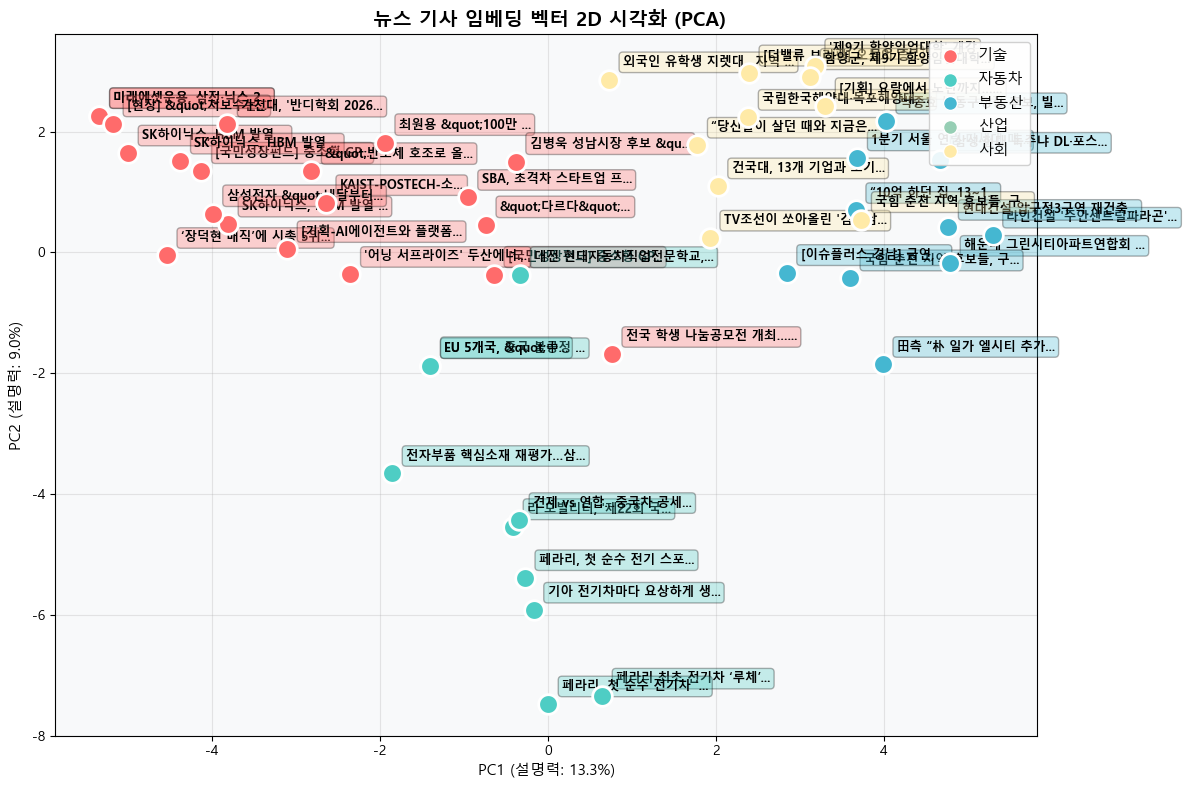


 의미적으로 유사한 기사들이 가까이 위치하는 것을 확인하세요!


In [59]:
# ============================================================
# 임베딩 벡터 2D 시각화 (PCA)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# matplotlib 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 뉴스 기사의 임베딩 벡터 가져오기
all_data = collection_news.get(
    include=["embeddings", "metadatas"]
)

embeddings = np.array(all_data['embeddings'])
categories = [m['category'] for m in all_data['metadatas']]
titles = [m['title'] for m in all_data['metadatas']]

# PCA로 2D 축소
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

# 시각화
fig, ax = plt.subplots(figsize=(12, 8))

# 카테고리별 색상
color_map = {
    "기술": "#FF6B6B",
    "자동차": "#4ECDC4",
    "부동산": "#45B7D1",
    "산업": "#96CEB4",
    "사회": "#FFEAA7",
}

for i, (x, y) in enumerate(coords):
    color = color_map.get(categories[i], "#999999")
    ax.scatter(x, y, c=color, s=200, edgecolors='white', linewidths=2, zorder=5)
    # 제목 줄이기
    short_title = titles[i][:15] + "..." if len(titles[i]) > 15 else titles[i]
    ax.annotate(short_title, (x, y), textcoords="offset points",
                xytext=(10, 10), fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

# 범례
for cat, color in color_map.items():
    ax.scatter([], [], c=color, s=100, label=cat, edgecolors='white')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

ax.set_title(' 뉴스 기사 임베딩 벡터 2D 시각화 (PCA)', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 (설명력: {pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 (설명력: {pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

print("\n 의미적으로 유사한 기사들이 가까이 위치하는 것을 확인하세요!")

### 그래프 DB
- Node, RelationShip(관계), 탐색(Traversal) 통해서 복잡한 관계를 효율적으로 쿼리하는 데이터베이스
- Node : 엔티티(사람, 장소, 물건 등)를 나타내는 기본단위
- RelationShip : 노드간의 연결, 방향과 타입 보유
- Property(속성) : Node, RelationShip에 붙는 key-value데이터
- Label : 노드의 타입 / 카테고리

### RDBMS vs Graph DB
- 테이블(행, 열)            노드 + 관계
- Join(외래키)              직접 연결
- 다중 Join(느림)           그래프 탐색(빠름)
- 쿼리(SQL)언어             Neo4j
- 정형데이터, 집계          관계중심 데이터

# [7교시]

In [7]:
# ### Neo4j 로컬 환경 실행 가이드
# - 1. DB 서버 켜기 (가장 먼저 실행, 검은 창 끄지 말 것)
#     - 탐색기 경로: C:\neo4j-community-2026.04.0\bin
#     - cmd 실행 후 명령어: neo4j console
#     - 맨 마지막 줄 'Started.' 문구 확인

# - 2. Neo4j 화면(모니터) 띄우기
#     - Neo4j Desktop 프로그램 실행
#     - 좌측 [Remote connections] 클릭
#     - 우측 [Connect] -> [Query] 클릭

# - 3. .env 파일 세팅 (프로젝트 폴더 내)
#     - NEO4J_URI=bolt://127.0.0.1:7687
#     - NEO4J_USER=neo4j
#     - NEO4J_PASSWORD=본인비밀번호

# - 4. 파이썬 연결 세팅 코드
# import os
# from dotenv import load_dotenv
# from neo4j import GraphDatabase

# load_dotenv(override=True)
# NEO4J_URI = os.getenv('NEO4J_URI')
# NEO4J_USER = os.getenv('NEO4J_USER')
# NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
# NEO4J_DATABASE = "neo4j"

# driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
# driver.verify_connectivity()
# neo4j_available = True

In [2]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

NEO4J_URI = os.getenv('NEO4J_URI')
NEO4J_USER = os.getenv('NEO4J_USER')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = "neo4j"
from neo4j import GraphDatabase
driver = GraphDatabase.driver(NEO4J_URI,auth=(NEO4J_USER,NEO4J_PASSWORD))
driver.verify_connectivity()
neo4j_available = True

In [3]:
# ### Cypher 기본 문법
# - 노드생성
#     - CREATE(p:Person {name:'kim', age:28})
# - 관계 생성
#     - MATCH(a:Person {name:'kim}),(b:Person {name:'lee'})  
#     - CREATE (a) -[:FRIEND{Since:2020}]->(b)   
# 패턴매칭
# (a)-[:friend]->(b)   a가 b의 친구

In [4]:
# 그래프 데이터 생성(Cypher 쿼리)

def run_cypher(query, parameters=None):
    """Neo4j에 Cypher 쿼리를 실행하고 결과를 반환합니다."""
    with driver.session(database=NEO4J_DATABASE) as session:
        result = session.run(query, parameters or {})
        return [record.data() for record in result]

if neo4j_available:
    # 기존 데이터 삭제
    run_cypher("MATCH (n) DETACH DELETE n")
    print("️ 기존 데이터 삭제 완료")
    
    # 노드 생성
    create_query = """
    CREATE (cs:Person {name: '김철수', age: 28, job: '개발자', city: '서울'})
    CREATE (yh:Person {name: '이영희', age: 32, job: '디자이너', city: '서울'})
    CREATE (ms:Person {name: '박민수', age: 25, job: '개발자', city: '부산'})
    CREATE (je:Person {name: '최지은', age: 30, job: 'PM', city: '서울'})
    CREATE (hj:Person {name: '정호진', age: 27, job: '데이터분석가', city: '대전'})
    CREATE (sj:Person {name: '한수진', age: 29, job: '개발자', city: '서울'})
    
    CREATE (cs)-[:FRIEND {since: 2020}]->(yh)
    CREATE (cs)-[:FRIEND {since: 2021}]->(ms)
    CREATE (yh)-[:COLLEAGUE {company: '테크Corp'}]->(je)
    CREATE (je)-[:MANAGES {since: 2022}]->(cs)
    CREATE (ms)-[:FRIEND {since: 2023}]->(hj)
    CREATE (hj)-[:COLLEAGUE {company: '데이터Lab'}]->(sj)
    CREATE (sj)-[:FRIEND {since: 2019}]->(cs)
    CREATE (yh)-[:FOLLOWS]->(hj)
    CREATE (je)-[:FOLLOWS]->(sj)
    
    RETURN count(*) as created
    """
    
    run_cypher(create_query)
    print(" Neo4j에 그래프 데이터 생성 완료!")
    
    # 확인
    result = run_cypher("MATCH (n:Person) RETURN n.name AS name, n.job AS job, n.city AS city")
    print(f"\n 생성된 노드:")
    for r in result:
        print(f"    {r['name']} — {r['job']}, {r['city']}")
else:
    print("️ Neo4j 서버에 연결되어 있지 않아 이 셀을 건너뜁니다.")
    print("   위의 Cypher 쿼리 코드를 읽으며 문법을 학습하세요.")

️ 기존 데이터 삭제 완료
 Neo4j에 그래프 데이터 생성 완료!

 생성된 노드:
    김철수 — 개발자, 서울
    이영희 — 디자이너, 서울
    박민수 — 개발자, 부산
    최지은 — PM, 서울
    정호진 — 데이터분석가, 대전
    한수진 — 개발자, 서울


In [5]:
if neo4j_available:
    print(" 1. 모든 FRIEND 관계 조회")
    print("="*50)
    results = run_cypher("""
        MATCH (a:Person)-[r:FRIEND]->(b:Person)
        RETURN a.name AS from_person, b.name AS to_person, r.since AS since
        ORDER BY r.since
    """)
    for r in results:
        print(f"  {r['from_person']} ──FRIEND──> {r['to_person']} (since {r['since']})")
    
    print(f"\n\n 2. 서울에 사는 개발자의 친구")
    print("="*50)
    results = run_cypher("""
        MATCH (a:Person {city: '서울', job: '개발자'})-[:FRIEND]->(b:Person)
        RETURN a.name AS person, b.name AS friend, b.city AS friend_city
    """)
    for r in results:
        print(f"  {r['person']}  {r['friend']} ({r['friend_city']})")
    
    print(f"\n\n 3. 2-hop 관계 탐색 (친구의 친구)")
    print("="*50)
    results = run_cypher("""
        MATCH (a:Person {name: '김철수'})-[:FRIEND]->()-[:FRIEND]->(fof:Person)
        WHERE fof.name <> '김철수'
        RETURN DISTINCT fof.name AS friend_of_friend, fof.job AS job
    """)
    for r in results:
        print(f"  김철수의 친구의 친구: {r['friend_of_friend']} ({r['job']})")
    
    print(f"\n\n 4. 최단 경로 탐색")
    print("="*50)
    results = run_cypher("""
        MATCH path = shortestPath(
            (a:Person {name: '김철수'})-[*]-(b:Person {name: '정호진'})
        )
        RETURN [node IN nodes(path) | node.name] AS path_nodes,
               length(path) AS hops
    """)
    for r in results:
        print(f"  경로: {'  '.join(r['path_nodes'])} ({r['hops']} hops)")

else:
    print("️ Neo4j 미연결 — Cypher 쿼리 코드를 읽으며 학습하세요.")
    print()
    print(" 위 코드에서 사용된 Cypher 패턴 정리:")
    print("   MATCH (a)-[r:TYPE]->(b)     : 패턴 매칭")
    print("   WHERE a.prop = 'value'       : 조건 필터링")
    print("   RETURN a.name, b.name        : 결과 반환")
    print("   (a)-[:FRIEND]->()-[:FRIEND]->(c) : 2-hop 탐색")
    print("   shortestPath((a)-[*]-(b))    : 최단 경로")

 1. 모든 FRIEND 관계 조회
  한수진 ──FRIEND──> 김철수 (since 2019)
  김철수 ──FRIEND──> 이영희 (since 2020)
  김철수 ──FRIEND──> 박민수 (since 2021)
  박민수 ──FRIEND──> 정호진 (since 2023)


 2. 서울에 사는 개발자의 친구
  김철수  이영희 (서울)
  김철수  박민수 (부산)
  한수진  김철수 (서울)


 3. 2-hop 관계 탐색 (친구의 친구)
  김철수의 친구의 친구: 정호진 (데이터분석가)


 4. 최단 경로 탐색
  경로: 김철수  이영희  정호진 (2 hops)


### PART1 VectorDB : 상품의미검색
- 상품설명을 임베딩해서 맥락 기반의 검색 수행
### PART2 GraphDB : 구매/리뷰 
- 유저-상품-리뷰간의 그래프생성 및 분석
### PART3 GraphRAG & 추천
- 의미검색결과에서 신뢰도(그래프 중심성)높은 상품 필터링

In [6]:
import chromadb
from chromadb.utils import embedding_functions
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

products = [
    {"id": "p1", "name": "프로그래밍용 고성능 노트북", "desc": "최신 14세대 CPU와 32GB RAM을 탑재하여 무거운 딥러닝 및 개발 작업에 최적화된 랩탑입니다.", "category": "가전"},
    {"id": "p2", "name": "초경량 사무용 랩탑", "desc": "1kg 미만의 가벼운 무게로 카페나 도서관에서 문서 작업 및 웹서핑을 하기에 매우 좋은 노트북.", "category": "가전"},
    {"id": "p3", "name": "전문가용 미러리스 카메라", "desc": "4K 60fps 동영상 촬영과 빠르고 정확한 AF를 지원하여 유튜버 및 프로 사진작가에게 적합한 카메라.", "category": "가전"},
    {"id": "p4", "name": "편안한 러닝화", "desc": "쿠셔닝이 뛰어나고 통풍이 잘 되어 장시간 달리기나 헬스장 운동 시 발의 피로를 최소화해주는 운동화.", "category": "패션"},
    {"id": "p5", "name": "방수 트레킹화", "desc": "고어텍스 소재로 비오는 날이나 거친 산악 지형에서도 발을 쾌적하게 보호하는 등산용 신발.", "category": "패션"}
]

# [8교시]

In [8]:
# 1. Chroma 인메모리 클라이언트 및 다국어 임베딩 설정
client = chromadb.Client()
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='paraphrase-multilingual-MiniLM-L12-v2'
)
# 기존 컬렉션 초기화 후 재생성
try:
    client.delete_collection('ecommerce')
except Exception:
    pass    
product_collection =  client.create_collection(
    name ='ecommerce',
    embedding_function=st_ef,
    metadata={'hnsw:space':'cosine'}
)
# 2. 가상의 이커머스 상품 데이터 (노트북, 카메라, 신발 등)
# 3. Vector DB에 데이터 삽입
product_collection.add(
    ids = [f'product_{i:03d}' for i, p in enumerate(products)],
    documents=[p['desc'] for p in products],
    metadatas=[
        { 'name':p['name'],'category':p['category']}
            for p in products        
    ]
)
# 4. 의미 기반 검색 테스트
query = '산에 갈 때 신기 좋은 튼튼한 신발'
results = product_collection.query(
    query_texts=[query],
    n_results=5  # top_5
)
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    similarity = 1- dist # 코사인거리->유사도 변환    
    print(similarity,doc,meta,dist)

c:\miniconda\envs\edu_env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


0.7859519720077515 고어텍스 소재로 비오는 날이나 거친 산악 지형에서도 발을 쾌적하게 보호하는 등산용 신발. {'category': '패션', 'name': '방수 트레킹화'} 0.21404802799224854
0.4105861186981201 쿠셔닝이 뛰어나고 통풍이 잘 되어 장시간 달리기나 헬스장 운동 시 발의 피로를 최소화해주는 운동화. {'name': '편안한 러닝화', 'category': '패션'} 0.5894138813018799
0.1638472080230713 1kg 미만의 가벼운 무게로 카페나 도서관에서 문서 작업 및 웹서핑을 하기에 매우 좋은 노트북. {'category': '가전', 'name': '초경량 사무용 랩탑'} 0.8361527919769287
0.07583683729171753 4K 60fps 동영상 촬영과 빠르고 정확한 AF를 지원하여 유튜버 및 프로 사진작가에게 적합한 카메라. {'name': '전문가용 미러리스 카메라', 'category': '가전'} 0.9241631627082825
-0.0030096769332885742 최신 14세대 CPU와 32GB RAM을 탑재하여 무거운 딥러닝 및 개발 작업에 최적화된 랩탑입니다. {'category': '가전', 'name': '프로그래밍용 고성능 노트북'} 1.0030096769332886


### 그래프 DB를 이용한 신뢰도 분석
- 제품검색은 VectorDB가 잘함
- 이 제품을 파는 판매자나 리뷰가 믿을만한가? -> 관계데이터인 그래프DB가 유리함
- 유저 - 상품간의 구매 및 리뷰 그래프 모델링

In [11]:
# 그래프 생성
G = nx.DiGraph()
# 상품 노드추가(VectorDB id 사용)
for p in products:
    G.add_node( p['id'], type='Product' , name = p['name']  )

# 유저노드 추가
users = ['User_A','User_B','User_C',"Spammer_1","Spammer_2"]
for u in users:
    G.add_node(u, type='User', name=u)
# 구매 및 추천 관계 추가
# 정상유저들의 패턴 : 여러 상품을 구매하고 교류
edges = [
    ("User_A", "p5", "PURCHASED"), ("User_A", "p4", "PURCHASED"),
    ("User_B", "p5", "PURCHASED"), ("User_B", "p1", "PURCHASED"),
    ("User_C", "p1", "PURCHASED"), ("User_C", "p3", "PURCHASED"),
    ("User_A", "User_B", "FOLLOWS"), ("User_B", "User_C", "FOLLOWS")
]
# 사기패턴 : 특정 스패머들이 특정 상품(p2)만 집중적으로 가짜 구매/리뷰
spam_edges = [
    ("Spammer_1", "p2", "PURCHASED"), ("Spammer_2", "p2", "PURCHASED"),
    ("Spammer_1", "p2", "REVIEWED_5_STAR"), ("Spammer_2", "p2", "REVIEWED_5_STAR"),
    ("Spammer_1", "Spammer_2", "FOLLOWS") # 자기들끼리만 연결됨
]

for src,dst,rel in edges + spam_edges:
    G.add_edge(src,dst,type=rel)

print(f'그래프생성 완료 : 노드 : {G.number_of_nodes()}  엣지 : {G.number_of_edges()}')

그래프생성 완료 : 노드 : 10  엣지 : 11


In [12]:
# 페이지랭크(PageRnak)알고리즘 : 상품의 진짜 신뢰도 분석
raw_pr_scores = nx.pagerank(G, alpha=0.85)

suspicious_users = {n for n, data in G.nodes(data=True) if data['type'] == 'User' and str(n).startswith('Spammer')}
trusted_nodes = [n for n in G.nodes() if n not in suspicious_users]
trusted_G = G.subgraph(trusted_nodes).copy()
pr_scores = nx.pagerank(trusted_G, alpha=0.85)

print("원본 그래프 PageRank (스팸 영향 포함)")
print("-" * 50)
for node, score in sorted(raw_pr_scores.items(), key=lambda x: -x[1]):
    node_data = G.nodes[node]
    node_type = node_data['type']
    name = node_data['name']
    bar = '*' * int(score * 80)
    print(f"[{node_type}] {name[:12]:<12} | 점수: {score:.3f} {bar}")

print("\n신뢰도 보정 PageRank (Spammer 제외)")
print("-" * 50)
for node, score in sorted(pr_scores.items(), key=lambda x: -x[1]):
    node_data = trusted_G.nodes[node]
    node_type = node_data['type']
    name = node_data['name']
    bar = '*' * int(score * 80)
    print(f"[{node_type}] {name[:12]:<12} | 점수: {score:.3f} {bar}")

원본 그래프 PageRank (스팸 영향 포함)
--------------------------------------------------
[Product] 초경량 사무용 랩탑   | 점수: 0.174 *************
[Product] 프로그래밍용 고성능 노 | 점수: 0.128 **********
[Product] 방수 트레킹화      | 점수: 0.109 ********
[Product] 전문가용 미러리스 카메 | 점수: 0.104 ********
[User] Spammer_2    | 점수: 0.094 *******
[User] User_C       | 점수: 0.090 *******
[Product] 편안한 러닝화      | 점수: 0.085 ******
[User] User_B       | 점수: 0.085 ******
[User] User_A       | 점수: 0.066 *****
[User] Spammer_1    | 점수: 0.066 *****

신뢰도 보정 PageRank (Spammer 제외)
--------------------------------------------------
[Product] 프로그래밍용 고성능 노 | 점수: 0.175 **************
[Product] 방수 트레킹화      | 점수: 0.148 ***********
[Product] 전문가용 미러리스 카메 | 점수: 0.142 ***********
[User] User_C       | 점수: 0.123 *********
[Product] 편안한 러닝화      | 점수: 0.116 *********
[User] User_B       | 점수: 0.116 *********
[Product] 초경량 사무용 랩탑   | 점수: 0.090 *******
[User] User_A       | 점수: 0.090 *******


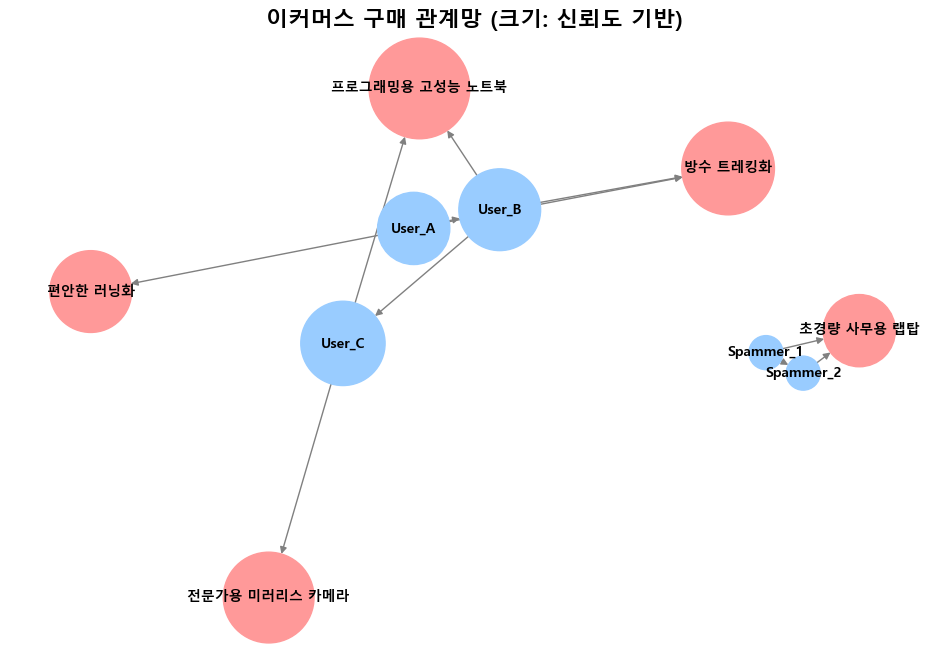

In [13]:
# 3. 그래프 시각화
fig, ax = plt.subplots(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 한글 라벨이 깨지지 않도록 폰트를 명시적으로 지정
label_font = 'Malgun Gothic'

# 노드 타입별 색상 지정
color_map = {'Product': '#FF9999', 'User': '#99CCFF'}
colors = [color_map[G.nodes[n]['type']] for n in G.nodes()]
sizes = [pr_scores.get(n, 0.02) * 30000 for n in G.nodes()] # 스팸 노드는 작은 기본 크기 사용

nx.draw(G, pos, with_labels=True, labels={n: G.nodes[n]['name'] for n in G.nodes()},
        node_color=colors, node_size=sizes, font_size=10, font_weight='bold', 
        font_family=label_font,
        edge_color='gray', arrows=True, ax=ax)
plt.title("이커머스 구매 관계망 (크기: 신뢰도 기반)", fontsize=16, fontweight='bold')
plt.show()


### part3 Vector DB + Graph DB

In [14]:
# 1. 사용자 질의
query = "카페에서 쓰기 좋은 코딩용 노트북"

# 2. Vector DB에서 1차 의미 검색 (Top 3)
results = product_collection.query(query_texts=[query], n_results=3)

print(" [1차 필터링] Vector DB 검색 결과 (의미 기반)")
print("-" * 50)
candidates = []
for doc, meta, dist, p_id in zip(results['documents'][0], results['metadatas'][0], results['distances'][0], results['ids'][0]):
    sim = 1 - dist
    candidates.append({"id": p_id, "name": meta['name'], "vector_score": sim})
    print(f"상품명: {meta['name']:<15} | Vector 유사도: {sim:.4f}")

# 3. Graph DB 신뢰도 융합 (Hybrid Scoring)
print("\n [최종 추천] Vector 유사도 + Graph 신뢰도 융합 결과")
print("-" * 50)

alpha = 0.6 # 벡터 유사도 비중
beta = 0.4  # 그래프 신뢰도 비중

for c in candidates:
    v_score = c['vector_score']
    # PageRank 점수 정규화 (가독성을 위해 10배 곱함)
    g_score = pr_scores.get(c['id'], 0) * 10 
    
    # 하이브리드 점수 산출
    final_score = (v_score * alpha) + (g_score * beta)
    c['final_score'] = final_score
    c['graph_score'] = g_score

# 최종 점수순 정렬
candidates.sort(key=lambda x: x['final_score'], reverse=True)

for i, c in enumerate(candidates):
    print(f"{i+1}위: {c['name']:<15}")
    print(f"    └ 합산 점수: {c['final_score']:.4f} (Vector: {c['vector_score']:.4f}, Graph: {c['graph_score']:.4f})")


 [1차 필터링] Vector DB 검색 결과 (의미 기반)
--------------------------------------------------
상품명: 초경량 사무용 랩탑      | Vector 유사도: 0.6709
상품명: 프로그래밍용 고성능 노트북  | Vector 유사도: 0.3848
상품명: 전문가용 미러리스 카메라   | Vector 유사도: 0.2273

 [최종 추천] Vector 유사도 + Graph 신뢰도 융합 결과
--------------------------------------------------
1위: 초경량 사무용 랩탑     
    └ 합산 점수: 0.4025 (Vector: 0.6709, Graph: 0.0000)
2위: 프로그래밍용 고성능 노트북 
    └ 합산 점수: 0.2309 (Vector: 0.3848, Graph: 0.0000)
3위: 전문가용 미러리스 카메라  
    └ 합산 점수: 0.1364 (Vector: 0.2273, Graph: 0.0000)
